In [29]:
import sys
from pathlib import Path
sys.path.append(str(Path('../../../src').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler


from utils.variants import VARIANT_DEFS, apply_variant


# --- Paths ---
BASE_DIR = Path("../../../data/out")
VAL_PATH = BASE_DIR / "dataset_validation_final.csv"
MODELS_DIR = BASE_DIR / "best_models_lstm/validation_lstm/models"
PLOTS_CUSTOM = BASE_DIR / "best_models_lstm/validation_lstm/plots_custom"
PLOTS_CUSTOM.mkdir(parents=True, exist_ok=True)

In [30]:
# ----------------------------------------------------------------------
# Dataset de validación externo
df_val = pd.read_csv("../../../data/out/dataset_validation_final.csv")
df_val["FECHA_HORA"] = pd.to_datetime(df_val["FECHA_HORA"], dayfirst=True, errors="coerce")
y_val = df_val["PRECIO"].astype("float32")

# Crear eje temporal manual
fechas = pd.date_range(start="2025-07-01 00:00", periods=len(y_val), freq="H")


def prepare_variant_data_for_lstm(df, scaler=None, fit=False, target_column='PRECIO',
                                  timesteps=24,
                                  categorical_numeric=["YEAR","MONTH","DAY","HORA","NIVEL_ENSO","DIA_SEMANA","FESTIVO"]):
    """
    Prepara secuencias para LSTM a partir de un DataFrame ya transformado por la variante.
    - Si fit=True, ajusta el scaler con los datos numéricos.
    - Si fit=False, solo transforma con el scaler ya entrenado.
    Devuelve X_seq, y_seq completos (sin split).
    """
    df = df.drop(columns=['FECHA_HORA'], errors='ignore')

    # Separar numéricas y categóricas
    numeric_cols = [c for c in df.columns if c not in categorical_numeric + [target_column]]
    X_num = df[numeric_cols].values.astype('float32') if numeric_cols else None
    X_cat = df[[c for c in categorical_numeric if c in df.columns]].values.astype('float32')
    y = df[target_column].values.astype('float32')

    # Escalar solo numéricas
    if X_num is not None:
        if fit:
            scaler.fit(X_num)
        X_num_scaled = scaler.transform(X_num)
        X_all = np.concatenate([X_num_scaled, X_cat], axis=1)
    else:
        X_all = X_cat

    # Construir secuencias
    X_seq, y_seq = [], []
    for i in range(len(X_all) - timesteps):
        X_seq.append(X_all[i:i+timesteps, :])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

# ----------------------------------------------------------------------
# Función para predecir con un modelo ya entrenado
def predict_with_lstm_variant(variant, config_name, df_val, timesteps=24):
    # 1. Reconstruir dataset de validación según la variante
    vdef = next(v for v in VARIANT_DEFS if v["name"] == variant)
    df_val_var, _ = apply_variant(df_val.copy(), vdef, date_col="FECHA_HORA")

    # 2. Preparar secuencias de validación (ajustando scaler sobre df_val)
    scaler = MinMaxScaler()
    X_val_seq, y_val_seq = prepare_variant_data_for_lstm(
        df_val_var, scaler=scaler, fit=True, timesteps=timesteps
    )

    # 3. Cargar modelo entrenado
    model_file = MODELS_DIR / f"{variant}_{config_name}.h5"
    model = load_model(model_file)

    # 4. Predecir
    y_pred = model.predict(X_val_seq, verbose=0).ravel()

    # 5. Alinear fechas
    fechas_seq = fechas[timesteps:]

    return y_val_seq, y_pred, fechas_seq

C:\Users\Camilo\AppData\Local\Temp\ipykernel_33264\3470804332.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas = pd.date_range(start="2025-07-01 00:00", periods=len(y_val), freq="H")


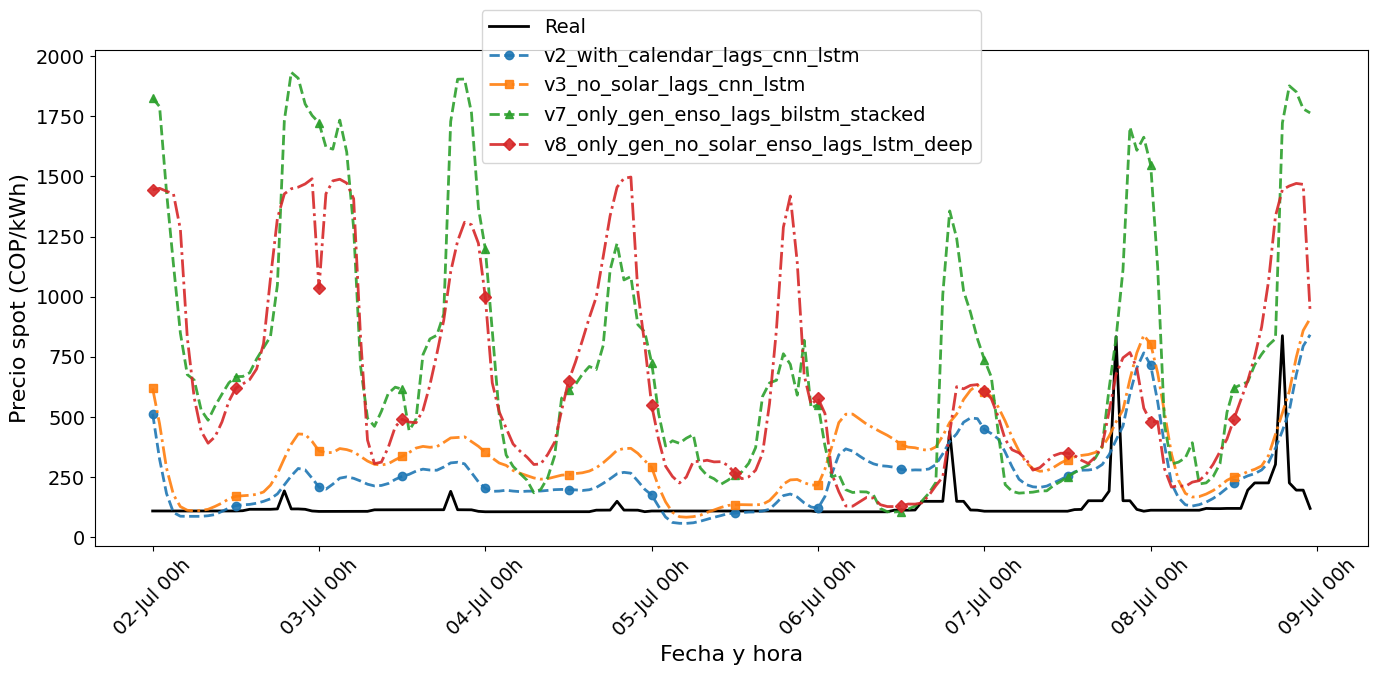

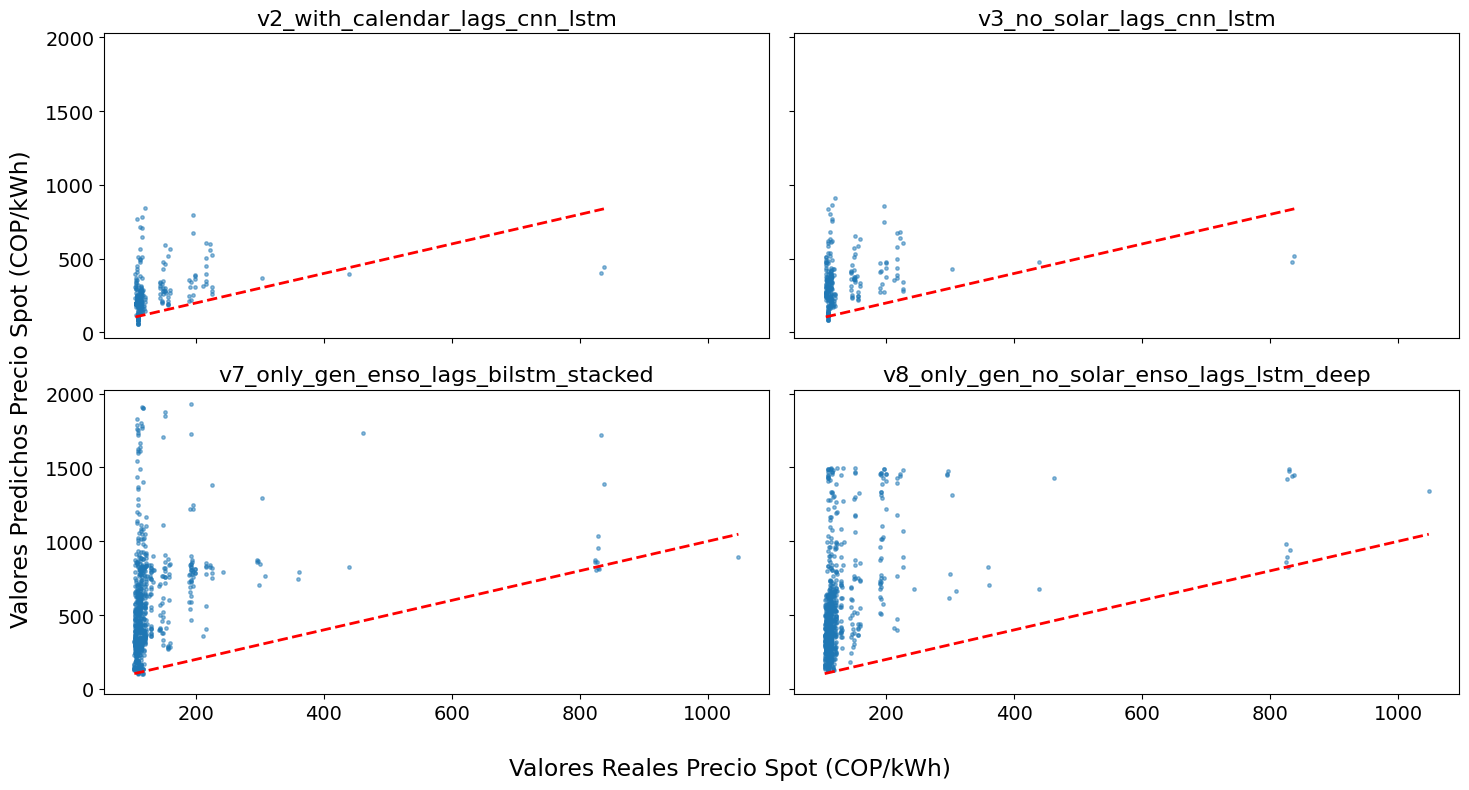

In [32]:
# Ajustar tamaño de fuentes en matplotlib
plt.rcParams.update({
    "font.size": 14,          # tamaño base
    "axes.titlesize": 16,     # títulos de ejes
    "axes.labelsize": 16,     # etiquetas de ejes
    "xtick.labelsize": 14,    # ticks eje X
    "ytick.labelsize": 14,    # ticks eje Y
    "legend.fontsize": 14     # leyenda
})


# ----------------------------------------------------------------------
# Top 3 modelos seleccionados
top_models_lstm = [
    ("v2_with_calendar_lags", "cnn_lstm"),
    ("v3_no_solar_lags", "cnn_lstm"),
    ("v7_only_gen_enso_lags", "bilstm_stacked"),
    ("v8_only_gen_no_solar_enso_lags", "lstm_deep")
]

predicciones_lstm = {}
for variant, config_name in top_models_lstm:
    y_seq, y_pred, fechas_seq = predict_with_lstm_variant(
        variant, config_name, df_val, timesteps=24
    )
    predicciones_lstm[f"{variant}_{config_name}"] = (y_seq, y_pred, fechas_seq)


# ----------------------------------------------------------------------
# 1. Predicciones vs reales (todos en una sola gráfica)
n_observations = 24 * 7  # 7 días

plt.figure(figsize=(14,7))
# Curva real destacada
y_seq_ref, _, fechas_seq_ref = next(iter(predicciones_lstm.values()))
plt.plot(fechas_seq_ref[:n_observations], y_seq_ref[:n_observations],
         label="Real", color="black", linewidth=2)

# Colores, estilos y marcadores
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]   # azul, naranja, verde, rojo
estilos = ["--", "-.", "--", "-."]                      # todos discontinuos
marcadores = ["o", "s", "^", "D"]                       # círculo, cuadrado, triángulo, rombo

# Curvas de predicción
for (name, (y_seq, y_pred, fechas_seq)), color, estilo, marker in zip(
    predicciones_lstm.items(), colores, estilos, marcadores
):
    plt.plot(fechas_seq[:n_observations], y_pred[:n_observations],
             label=name, color=color, linestyle=estilo,
             marker=marker, markersize=6, markevery=12,
             linewidth=2, alpha=0.9)

# Ejes y leyenda
plt.xlabel("Fecha y hora")
plt.ylabel("Precio spot (COP/kWh)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=45)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1))
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)
plt.tight_layout()

# Guardar y mostrar
plt.savefig(PLOTS_CUSTOM / "pred_top_lstm_solar.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()


# ----------------------------------------------------------------------
# 2. Scatter plots (subplots comparativos)
fig, axes = plt.subplots(2, 2, figsize=(15,8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, (y_seq, y_pred, _)) in zip(axes, predicciones_lstm.items()):
    lims = [y_seq.min(), y_seq.max()]
    ax.scatter(y_seq, y_pred, s=6, alpha=0.5)
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_title(name)

fig.supxlabel("Valores Reales Precio Spot (COP/kWh)")
fig.supylabel("Valores Predichos Precio Spot (COP/kWh)")
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "scatter_top_solar_lstm.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()


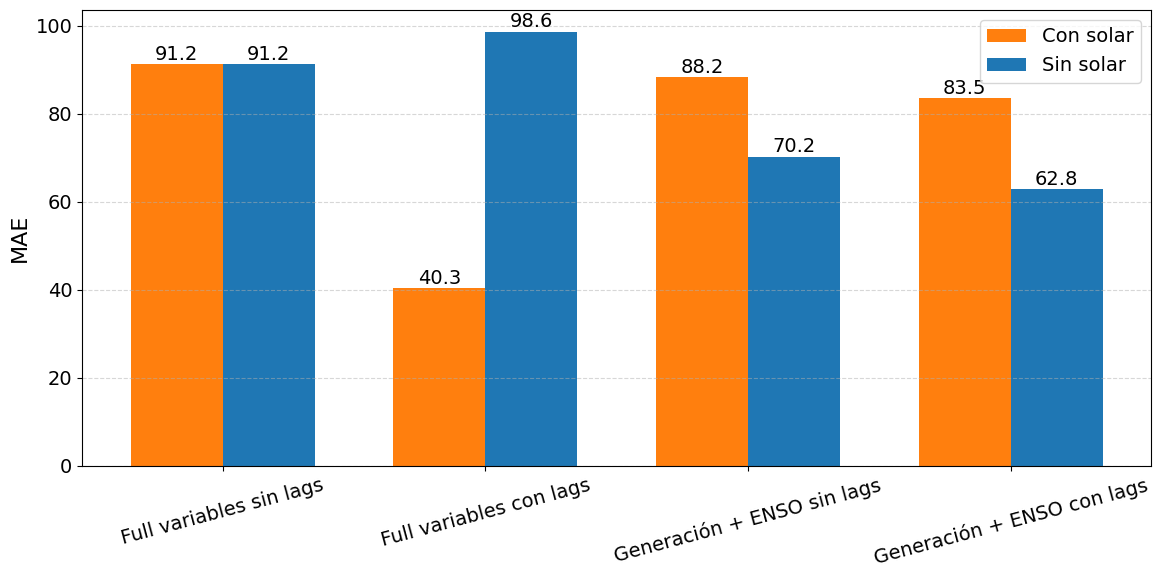

In [33]:
# --- Cargar el archivo Excel ---
ruta = "../../../data/out/best_models_lstm/validation_lstm/validation_lstm_metrics.xlsx"
df = pd.read_excel(ruta)

# --- Definir pares de modelos por bloque ---
pares = [
    ("v2_with_calendar", "v3_no_solar"),               # Calendario sin rezagos
    ("v2_with_calendar_lags", "v3_no_solar_lags"),     # Calendario + rezagos
    ("v7_only_gen_enso", "v8_only_gen_no_solar_enso"), # ENSO sin rezagos
    ("v7_only_gen_enso_lags", "v8_only_gen_no_solar_enso_lags")  # ENSO + rezagos
]

# --- Nombres de bloques intuitivos ---
labels = [
    "Full variables sin lags",
    "Full variables con lags",
    "Generación + ENSO sin lags",
    "Generación + ENSO con lags"
]

# --- Extraer MAE por modelo ---
mae_con_solar = [df.loc[df["variant"] == a, "MAE"].values[0] for a, b in pares]
mae_sin_solar = [df.loc[df["variant"] == b, "MAE"].values[0] for a, b in pares]

# --- Preparar gráfico ---
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, mae_con_solar, width, label="Con solar", color="#ff7f0e")
plt.bar(x + width/2, mae_sin_solar, width, label="Sin solar", color="#1f77b4")

# --- Etiquetas encima de cada barra ---
for i in range(len(x)):
    plt.text(x[i] - width/2, mae_con_solar[i] + 1, f"{mae_con_solar[i]:.1f}", ha="center")
    plt.text(x[i] + width/2, mae_sin_solar[i] + 1, f"{mae_sin_solar[i]:.1f}", ha="center")

# --- Estética ---
plt.ylabel("MAE")
plt.legend(loc="upper right")
plt.xticks(x, labels, rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "barras_mae_solar_vs_no.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

